# Exercise 1.6 

In [1]:
using Plots
using BenchmarkTools

In [2]:
function N(x, i, VX)
    M = length(VX)
    if i == 1 
        x1, x2 = VX[1], VX[2]
        if x1 <= x && x <= x2 
            1 - (x - x1) / (x2 - x1)
        else 0 
        end 
    elseif i == M 
        x_Mm1, x_M = VX[M-1], VX[M]
        if x_Mm1 <= x && x <= x_M
            (x - x_Mm1) / (x_M - x_Mm1)
        else 0
        end 
    elseif 2 <= i && i <= (M - 1)
        x_im1, x_i, x_ip1 = VX[i-1], VX[i], VX[i+1]
        if x_im1 <= x && x <= x_i 
            (x - x_im1) / (x_i - x_im1)
        elseif x_i <= x && x <= x_ip1
            1 - (x - x_i) / (x_ip1 - x_i) 
        else 0 
        end 
    end 
end

N(0.6, 1, [0 0.5 1.0])

0

In [3]:
function u(x)
    exp(-800 * (x - 0.4)^2) + 0.25 * exp(-40 * (x - 0.8)^2)
end

@btime u.([1 2]) # call with u. for vector! 

  56.148 ns (2 allocations: 160 bytes)


1×2 Matrix{Float64}:
 0.0504741  2.41311e-26

In [4]:
function u_I(x, VX)
    M = length(VX)
    u_i_list = u.(VX)
    res = 0
    for i in 1:M
        res += u_i_list[i] * N(x, i, VX)
    end 

    return res
end

u_I.([0.5 0.6], [[0.0 0.5 1.0]])

1×2 Matrix{Float64}:
 0.00716639  0.0158279

## a) 

In [5]:
VX = [0.0 0.2 0.4 0.6 0.8 1.0]
for (x_i, x_ip1) in zip(VX[1:end-1], VX[2:end])
    print("$x_i $x_ip1 \n")
end

0.0 0.2 
0.2 0.4 
0.4 0.6 
0.6 0.8 
0.8 1.0 


In [14]:
function compute_error_decrease(fun, VX, EToV)
    M = length(VX)
    err_list = []
    num = 1_000 # must be even! 
    for (x_i, x_ip1) in zip(VX[1:end-1], VX[2:end])
        x_i_new = x_i + (x_ip1 - x_i) / 2 
        x_arr = LinRange(x_i, x_ip1, num)
        h = (x_ip1 - x_i) / num 

        u_I_h = u_I.(x_arr, [[x_i, x_ip1]])

        half = div(num, 2) 

        u_I_h_refined_1 = u_I.(x_arr[1:half-1], [[x_i, x_i_new]])
        u_I_h_refined_2 = u_I.(x_arr[half:end], [[x_i_new, x_ip1]])
        u_I_h_refined = [u_I_h_refined_1; u_I_h_refined_2]

        # approximate the ||.||_2 by the sum 
        err = sqrt(sum(
            (u_I_h - u_I_h_refined).^2 .* h 
        )) 

        err_list = [err_list; err]
    end 

    return err_list
end 

compute_error_decrease("", [0 0.5 1], "")

2-element Vector{Any}:
 0.0014615299352051308
 0.08042521084832112

## b)

I interpret this function as given [0, 0.5, 1.0] and [1, 0] then the result is [0, 0.25, 0.5, 1.0] and similarly [0, 0.5, 1.0] and [1, 1] becomes [0, 0.25, 0.5, 0.75, 1.0]

In [19]:
# Still NOT using EToVcoarse 
function refine_marked(EToVcoarse, xcoarse, idxMarked)
    EToVfine = EToVcoarse
    xfine = xcoarse
    
    for (i, idx) in enumerate(idxMarked)
        if idx == 1 
            x_i, x_ip1 = xcoarse[i], xcoarse[i+1]
            dist = (x_ip1 - x_i) / 2
            x_new = x_i + dist 
            
            insert!(xfine, i+1, x_new)
            insert!(idxMarked, i+1, 0)
        end
    end 

    return EToVfine, xfine
end 

refine_marked("", [0.0, 0.5, 1.0], [0, 1])

("", [0.0, 0.5, 0.75, 1.0])

## c)

I'm unsure about the different criteria! 

In [8]:
xcoarse_initial = [0, 0.5, 1.0]
delta_err_i = 10^-4

0.00010000000000000002

In [9]:
function calc()
    idxMarked = [1, 1]
    xfine = xcoarse_initial
    while sum(idxMarked) != 0
        idxMarked = Int.(compute_error_decrease("", xfine, "") .> delta_err_i)
        _, xfine = refine_marked("", xfine, idxMarked)
    end 

    return xfine
end 

@time calc() 
@time xfine = calc()
length(xfine)

 10.635265 seconds (57.32 M allocations: 46.510 GiB, 25.10% gc time, 1.40% compilation time)
  4.280940 seconds (16.86 M allocations: 21.675 GiB, 27.52% gc time)


73652

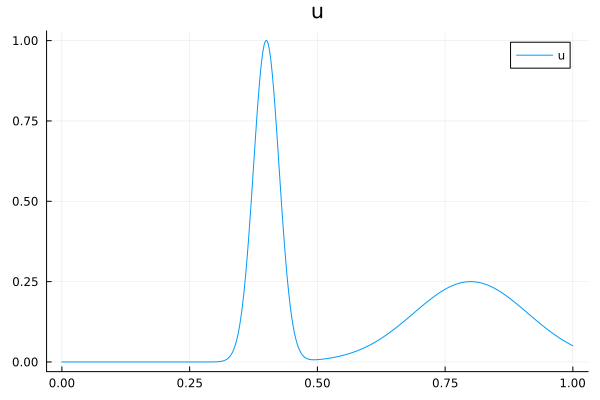

In [10]:
x_arr = LinRange(0, 1, 1_000)
y_arr = u.(x_arr)
plot(x_arr, y_arr, title = "u", label="u")

In [11]:
y_arr_initial = u_I.(x_arr, [[0 0.5 1.0]])
y_arr_fine = u_I.(x_arr, [xfine]);

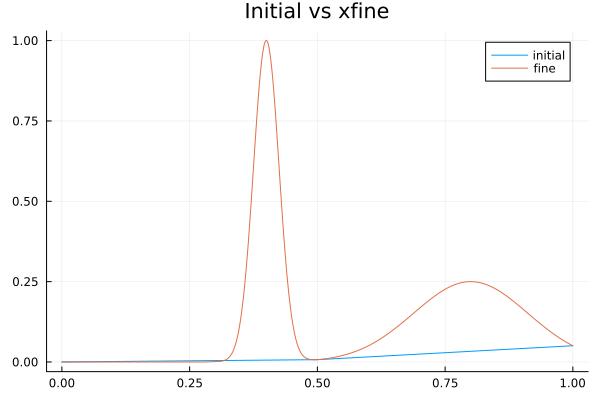

In [12]:
plot(x_arr, [y_arr_initial, y_arr_fine], title = "Initial vs xfine", label=["initial" "fine"])

Lots of points but look good

## d)

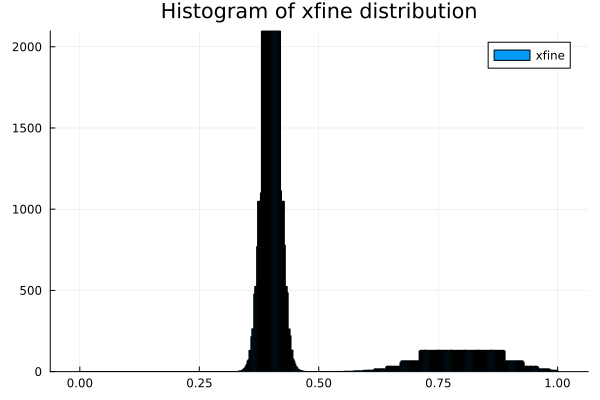

In [13]:
histogram(xfine, title = "Histogram of xfine distribution", label="xfine")